# 1. Imports and configs

In [1]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor, Pool
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
from joblib import Parallel, delayed
from pathlib import Path
from numba import njit, prange
import matplotlib.pyplot as plt
import lightgbm as lgb
import multiprocessing
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import joblib
import optuna
import time
import os
 
warnings.filterwarnings("ignore")

In [2]:
class CFG:
    dataset_path = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")
    artifacts_path = Path("/kaggle/input/datasets/ravaghi/wellbore-geology-prediction-artifacts")
    seed = 42
    n_splits = 5
    cv = GroupKFold(n_splits=n_splits)
    metric = root_mean_squared_error

# 2. Data loading and preprocessing

In [3]:
SEED = 42; np.random.seed(SEED)
NCPU = min(4, multiprocessing.cpu_count())
 
FORMATIONS = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
PLANE_K = 10; DENSE_SPW = 60; DENSE_K = 20; N_SPLITS = 5
 
BEAMS = [
    (10, 20.0, 144.0, 2, "cons"),
    (10,  8.0,  64.0, 2, "loose"),
    ( 8, 35.0, 220.0, 1, "vcons"),
    (10, 14.0,  90.0, 5, "sm5"),
    (20,  4.0,  36.0, 3, "vloose"),
    (12, 12.0, 100.0, 3, "mid"),
    (15, 25.0, 180.0, 2, "stiff"),
]
 
PF_N = 600; ANCC_N = 600
PF_MOM = 0.993; PF_VN = 0.005; PF_PN = 0.01
PF_GR_SIG_MIN = 10.; PF_GR_SIG_MAX = 60.; PF_GR_SIG_DEF = 30.
PF_INIT_V_STD = 0.02; PF_INIT_SPR = 0.5; PF_RESAMP = 0.5
PF_ROUGH_P = 0.2; PF_ROUGH_V = 0.003; PF_GR_WIN = 5; PF_GR_WT = 0.3
ANCC_ALPHA = 0.998; ANCC_RN = 0.002; ANCC_PN = 0.005
ANCC_IR = 0.01; ANCC_IS = 0.3; ANCC_RP = 0.1; ANCC_RR = 0.001
 
DTW_RADII = (20, 50, 100, 200)
DTW_STOCH_K = 12
DTW_STOCH_TEMP = 3.0
 
 
@njit(cache=True)
def _interp1(grid, v, vmin, step):
    i = int((v - vmin) / step)
    if i < 0: return grid[0]
    n = len(grid) - 1
    if i >= n: return grid[n]
    t = (v - vmin) / step - i
    return grid[i] * (1. - t) + grid[i + 1] * t
 
 
@njit(cache=True)
def _resamp(pos, aux, w, N, rp, rv):
    cum = np.zeros(N + 1)
    for j in range(N): cum[j + 1] = cum[j] + w[j]
    u0 = np.random.uniform(0., 1. / N)
    np2 = np.empty(N); na = np.empty(N); ci = 0
    for j in range(N):
        u = u0 + j / N
        while ci < N - 1 and cum[ci + 1] < u: ci += 1
        np2[j] = pos[ci] + rp * np.random.randn()
        na[j] = aux[ci] + rv * np.random.randn()
    return np2, na
 
 
@njit(cache=True)
def _beam_jit(sgr, tw_gr, si, BS, mc, es):
    n = len(sgr); nt = len(tw_gr); MAX = BS * 6
    bidx = np.zeros(BS, np.int64); bidx[0] = si
    bcost = np.full(BS, 1e30);     bcost[0] = 0.; bn = np.int64(1)
    hI = np.zeros((n, BS), np.int64); hP = np.zeros((n, BS), np.int64)
    cI = np.zeros(MAX, np.int64); cC = np.full(MAX, 1e30); cP = np.zeros(MAX, np.int64)
    for step in range(n):
        gv = sgr[step]; nc = np.int64(0)
        for bi in range(bn):
            idx = bidx[bi]; cost = bcost[bi]
            for d in range(-2, 3):
                ni = idx + d
                if ni < 0 or ni >= nt: continue
                tot = cost + (gv - tw_gr[ni]) ** 2 / es + mc * (d if d >= 0 else -d)
                fnd = np.int64(-1)
                for ci in range(nc):
                    if cI[ci] == ni: fnd = ci; break
                if fnd >= 0:
                    if tot < cC[fnd]: cC[fnd] = tot; cP[fnd] = bi
                else:
                    if nc < MAX: cI[nc] = ni; cC[nc] = tot; cP[nc] = bi; nc += 1
        kept = min(BS, nc)
        for i in range(kept):
            mi = i
            for j in range(i + 1, nc):
                if cC[j] < cC[mi]: mi = j
            if mi != i:
                cI[i], cI[mi] = cI[mi], cI[i]
                cC[i], cC[mi] = cC[mi], cC[i]
                cP[i], cP[mi] = cP[mi], cP[i]
        hI[step, :kept] = cI[:kept]; hP[step, :kept] = cP[:kept]
        bidx[:kept] = cI[:kept]; bcost[:kept] = cC[:kept]; bn = kept
    best = np.int64(0)
    for b in range(1, bn):
        if bcost[b] < bcost[best]: best = b
    path = np.zeros(n, np.int64); b = best
    for s in range(n - 1, -1, -1): path[s] = hI[s, b]; b = hP[s, b]
    return path
 
 
@njit(cache=True)
def _dtw_sakoe_chiba(query, ref, radius):
    """
    Constrained DTW with Sakoe-Chiba band.
    Returns (cost_matrix, accumulated_cost_matrix, path_i, path_j).
    Uses slanted band: diagonal from (0,0) to (N-1,M-1).
    """
    N = len(query); M = len(ref)
    INF = 1e18
    D = np.full((N, M), INF)
 
    slope = (M - 1.0) / max(N - 1.0, 1.0)
    for i in range(N):
        j_center = int(round(i * slope))
        j_lo = max(0, j_center - radius)
        j_hi = min(M - 1, j_center + radius)
        for j in range(j_lo, j_hi + 1):
            cost = (query[i] - ref[j]) ** 2
            if i == 0 and j == 0:
                D[i, j] = cost
            elif i == 0:
                prev = D[i, j - 1]
                D[i, j] = cost + (prev if prev < INF else INF)
            elif j == 0:
                prev = D[i - 1, j]
                D[i, j] = cost + (prev if prev < INF else INF)
            else:
                a = D[i - 1, j - 1]
                b = D[i - 1, j]
                c = D[i, j - 1]
                mn = a if a < b else b
                mn = mn if mn < c else c
                D[i, j] = cost + (mn if mn < INF else INF)
 
    i = N - 1; j = M - 1
    pi = np.zeros(N + M, np.int64)
    pj = np.zeros(N + M, np.int64)
    k = 0
    while i > 0 or j > 0:
        pi[k] = i; pj[k] = j; k += 1
        if i == 0:
            j -= 1
        elif j == 0:
            i -= 1
        else:
            a = D[i - 1, j - 1]; b = D[i - 1, j]; c = D[i, j - 1]
            if a <= b and a <= c:
                i -= 1; j -= 1
            elif b <= c:
                i -= 1
            else:
                j -= 1
    pi[k] = 0; pj[k] = 0; k += 1
    return D, pi[:k], pj[:k]
 
 
@njit(cache=True)
def _dtw_path_to_tvt(pi, pj, tw_tvt, N):
    """
    Convert DTW warping path to per-query-sample TVT estimate.
    For each query index i, find the corresponding typewell index j,
    then look up tw_tvt[j].
    """
    j_for_i = np.zeros(N, np.int64)
    for k in range(len(pi)):
        j_for_i[pi[k]] = pj[k]
    result = np.empty(N, np.float32)
    for i in range(N):
        result[i] = tw_tvt[j_for_i[i]]
    return result
 
 
@njit(cache=True)
def _dtw_path_slope(pi, pj, N, smooth_win=5):
    """
    Compute local slope dj/di along the warping path — encodes TVT rate.
    """
    j_for_i = np.zeros(N, np.float64)
    for k in range(len(pi)):
        j_for_i[pi[k]] = float(pj[k])
 
    slope = np.zeros(N, np.float32)
    hw = smooth_win // 2
    for i in range(N):
        i0 = max(0, i - hw); i1 = min(N - 1, i + hw)
        if i1 > i0:
            slope[i] = float((j_for_i[i1] - j_for_i[i0]) / (i1 - i0))
        else:
            slope[i] = 1.0
    return slope
 
 
@njit(cache=True)
def _dtw_stochastic_realizations(query, ref, radius, K, temperature):
    """
    Stochastic DTW: sample K realizations of the warping path by adding
    Gumbel noise to the cost matrix before traceback.
    Returns (K, N) array of typewell indices per realization.
    """
    N = len(query); M = len(ref)
    INF = 1e18
    slope = (M - 1.0) / max(N - 1.0, 1.0)
 
    D_base = np.full((N, M), INF)
    for i in range(N):
        j_center = int(round(i * slope))
        j_lo = max(0, j_center - radius)
        j_hi = min(M - 1, j_center + radius)
        for j in range(j_lo, j_hi + 1):
            D_base[i, j] = (query[i] - ref[j]) ** 2
 
    paths = np.zeros((K, N), np.int64)
    for k in range(K):
        D = np.full((N, M), INF)
        for i in range(N):
            j_center = int(round(i * slope))
            j_lo = max(0, j_center - radius)
            j_hi = min(M - 1, j_center + radius)
            for j in range(j_lo, j_hi + 1):
                noise = -temperature * np.log(-np.log(np.random.uniform(1e-10, 1.0)))
                cost = D_base[i, j] + noise
                if i == 0 and j == 0:
                    D[i, j] = cost
                elif i == 0:
                    prev = D[i, j - 1]
                    D[i, j] = cost + (prev if prev < INF else INF)
                elif j == 0:
                    prev = D[i - 1, j]
                    D[i, j] = cost + (prev if prev < INF else INF)
                else:
                    a = D[i - 1, j - 1]; b = D[i - 1, j]; c = D[i, j - 1]
                    mn = a if a < b else b
                    mn = mn if mn < c else c
                    D[i, j] = cost + (mn if mn < INF else INF)
 
        i = N - 1; j = M - 1
        j_for_i = np.zeros(N, np.int64)
        while i > 0 or j > 0:
            j_for_i[i] = j
            if i == 0:
                j -= 1
            elif j == 0:
                i -= 1
            else:
                a = D[i - 1, j - 1]; b = D[i - 1, j]; c = D[i, j - 1]
                if a <= b and a <= c:
                    i -= 1; j -= 1
                elif b <= c:
                    i -= 1
                else:
                    j -= 1
        j_for_i[0] = j
        paths[k] = j_for_i
 
    return paths
 
 
@njit(cache=True)
def _pf_ancc(md_v, z_v, gr_v, gg, vmin, step, gs, ls, ir, N,
             ALPHA, RN, PN, IS, RP, RR, RESAMP):
    pos = np.empty(N); rate = np.empty(N); w = np.ones(N) / N
    for j in range(N):
        pos[j] = ls + IS * np.random.randn()
        rate[j] = ir + 0.01 * np.random.randn()
    pts = np.empty(len(md_v)); std_ = np.empty(len(md_v)); pm = md_v[0] - 1.
    for i in range(len(md_v)):
        dm = md_v[i] - pm; dm = max(dm, 1.)
        for j in range(N):
            rate[j] = ALPHA * rate[j] + RN * np.random.randn()
            pos[j] += rate[j] * dm + PN * np.random.randn()
            tvt_j = pos[j] - z_v[i]
            tvt_j = max(tvt_j, vmin - 50.); tvt_j = min(tvt_j, vmin + len(gg) * step + 50.)
            pos[j] = tvt_j + z_v[i]
        if not np.isnan(gr_v[i]):
            ws = 0.
            for j in range(N):
                eg = _interp1(gg, pos[j] - z_v[i], vmin, step)
                d = (gr_v[i] - eg) / gs
                lk = max(np.exp(-0.5 * d * d) if d * d < 600. else 0., 1e-300)
                w[j] *= lk; ws += w[j]
            if ws > 0.:
                for j in range(N): w[j] /= ws
            else:
                for j in range(N): w[j] = 1. / N
        ne = 0.
        for j in range(N): ne += w[j] * w[j]
        if 1. / ne < RESAMP * N:
            pos, rate = _resamp(pos, rate, w, N, RP, RR)
            for j in range(N): w[j] = 1. / N
        tv = 0.
        for j in range(N): tv += w[j] * (pos[j] - z_v[i])
        pts[i] = tv; va = 0.
        for j in range(N): va += w[j] * (pos[j] - z_v[i] - tv) ** 2
        std_[i] = va ** 0.5; pm = md_v[i]
    return pts, std_
 
 
@njit(cache=True)
def _pf_z(md_v, z_v, gr_v, gr_sm_v, gg_p, gg_s, vmin, step,
          gs, ip, iv, beta, icpt, zsig, N,
          MOM, VN, PN, GR_WT, RP, RV, RESAMP):
    pos = np.empty(N); vel = np.empty(N); w = np.ones(N) / N
    for j in range(N):
        pos[j] = ip + 0.5 * np.random.randn()
        vel[j] = iv + 0.02 * np.random.randn()
    pts = np.empty(len(md_v)); std_ = np.empty(len(md_v)); pm = md_v[0] - 1.; pz = z_v[0] - 1.
    for i in range(len(md_v)):
        dm = md_v[i] - pm; dm = max(dm, 1.)
        dzd = (z_v[i] - pz) / dm; ve = beta * dzd + icpt
        for j in range(N):
            vel[j] = MOM * vel[j] + VN * np.random.randn()
            pos[j] += vel[j] * dm + PN * np.random.randn()
            pos[j] = max(pos[j], vmin - 50.); pos[j] = min(pos[j], vmin + len(gg_p) * step + 50.)
        if not np.isnan(gr_v[i]):
            ws = 0.
            for j in range(N):
                ep = _interp1(gg_p, pos[j], vmin, step)
                dp = (gr_v[i] - ep) / gs
                lp = max(np.exp(-0.5 * dp * dp) if dp * dp < 600. else 0., 1e-300)
                if not np.isnan(gr_sm_v[i]):
                    es = _interp1(gg_s, pos[j], vmin, step)
                    ds = (gr_sm_v[i] - es) / (gs * 1.5)
                    ls = max(np.exp(-0.5 * ds * ds) if ds * ds < 600. else 0., 1e-300)
                    lk = (1. - GR_WT) * lp + GR_WT * ls
                else:
                    lk = lp
                lk = max(lk, 1e-300); w[j] *= lk; ws += w[j]
            if ws > 0.:
                for j in range(N): w[j] /= ws
            else:
                for j in range(N): w[j] = 1. / N
        ws2 = 0.
        for j in range(N):
            dv = (vel[j] - ve) / max(zsig * 2., 0.005)
            lz = max(np.exp(-0.5 * dv * dv) if dv * dv < 600. else 0., 1e-300)
            w[j] *= lz; ws2 += w[j]
        if ws2 > 0.:
            for j in range(N): w[j] /= ws2
        else:
            for j in range(N): w[j] = 1. / N
        ne = 0.
        for j in range(N): ne += w[j] * w[j]
        if 1. / ne < RESAMP * N:
            pos, vel = _resamp(pos, vel, w, N, RP, RV)
            for j in range(N): w[j] = 1. / N
        wm = 0.
        for j in range(N): wm += w[j] * pos[j]
        pts[i] = wm; va = 0.
        for j in range(N): va += w[j] * (pos[j] - wm) ** 2
        std_[i] = va ** 0.5; pm = md_v[i]; pz = z_v[i]
    return pts, std_
 
 
def _grid(tw_tvt, tw_gr, step=0.2):
    tmin = float(tw_tvt.min()); tmax = float(tw_tvt.max())
    tvt_g = np.arange(tmin, tmax + step, step)
    return np.interp(tvt_g, tw_tvt, tw_gr).astype(np.float64), float(tmin), float(step)
 
 
def _gr_sig(hw, tw_tvt, tw_gr):
    kn = hw[hw['TVT_input'].notna() & hw['GR'].notna()]
    if len(kn) < 20: return float(PF_GR_SIG_DEF)
    return float(np.clip(np.std(kn['GR'].values - np.interp(kn['TVT_input'].values, tw_tvt, tw_gr)),
                         PF_GR_SIG_MIN, PF_GR_SIG_MAX))
 
 
def _nn(arr, v):
    i = int(np.searchsorted(arr, v, 'left'))
    if i >= len(arr): return len(arr) - 1
    if i > 0 and abs(arr[i - 1] - v) <= abs(arr[i] - v): return i - 1
    return i
 
 
def _smooth(vals, fb, r):
    s = pd.Series(vals, dtype='float32').interpolate(limit_direction='both').fillna(fb)
    return (s.rolling(r * 2 + 1, center=True, min_periods=1).mean() if r > 0 else s).to_numpy(np.float32)
 
 
def beam_search(gr_h, tw_tvt, tw_gr, start_tvt, bs, mc, es, r):
    si = _nn(tw_tvt, start_tvt)
    sgr = _smooth(gr_h, float(np.nanmean(tw_gr)), r).astype(np.float64)
    path = _beam_jit(sgr, tw_gr.astype(np.float64), si, bs, float(mc), float(es))
    return tw_tvt[path].astype(np.float32)
 
 
def run_pf_ancc(hw, tw_tvt, tw_gr, N=ANCC_N):
    gs = _gr_sig(hw, tw_tvt, tw_gr)
    kn = hw[hw['TVT_input'].notna()]; ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0: return np.array([]), np.array([])
    ls = float(kn['TVT_input'].iloc[-1] + kn['Z'].iloc[-1])
    tail = kn.tail(30); dt = np.diff(tail['TVT_input'].values)
    dz = np.diff(tail['Z'].values); dm = np.diff(tail['MD'].values); m = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.
    gg, gmin, gst = _grid(tw_tvt, tw_gr)
    pts, std = _pf_ancc(ev['MD'].values.astype(np.float64), ev['Z'].values.astype(np.float64),
                        ev['GR'].values.astype(np.float64), gg, gmin, gst,
                        gs, ls, ir, N, ANCC_ALPHA, ANCC_RN, ANCC_PN, ANCC_IS, ANCC_RP, ANCC_RR, PF_RESAMP)
    return pts.astype(np.float32), std.astype(np.float32)
 
 
def run_pf_z(hw, tw_tvt, tw_gr, N=PF_N):
    gs = _gr_sig(hw, tw_tvt, tw_gr)
    tw_s = pd.Series(tw_gr).rolling(PF_GR_WIN, center=True, min_periods=1).mean().values.astype(np.float32)
    kna = hw[hw['TVT_input'].notna()]; ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0: return np.array([]), np.array([])
    dz_k = np.diff(kna['Z'].values); dvt = np.diff(kna['TVT_input'].values)
    dmd_k = np.diff(kna['MD'].values); m2 = dmd_k > 0
    if m2.sum() >= 10:
        vz = dz_k[m2] / dmd_k[m2]; vt = dvt[m2] / dmd_k[m2]
        A = np.column_stack([vz, np.ones_like(vz)]); c, _, _, _ = np.linalg.lstsq(A, vt, rcond=None)
        beta, icpt, zsig = float(c[0]), float(c[1]), max(float(np.std(vt - (c[0] * vz + c[1]))), 0.001)
    else:
        beta, icpt, zsig = -1., 0., 0.1
    t2 = kna.tail(20); dvt2 = np.diff(t2['TVT_input'].values); dmd2 = np.diff(t2['MD'].values); m3 = dmd2 > 0
    iv = float(np.median(dvt2[m3] / dmd2[m3])) if m3.sum() >= 3 else 0.
    gg, gmin, gst = _grid(tw_tvt, tw_gr)
    gs2, _, _ = _grid(tw_tvt, tw_s)
    gr_sm = hw['GR'].rolling(PF_GR_WIN, center=True, min_periods=1).mean()
    pts, std = _pf_z(ev['MD'].values.astype(np.float64), ev['Z'].values.astype(np.float64),
                     ev['GR'].values.astype(np.float64),
                     gr_sm.loc[ev.index].values.astype(np.float64),
                     gg, gs2, gmin, gst, gs, float(kna['TVT_input'].iloc[-1]), iv,
                     beta, icpt, zsig, N,
                     PF_MOM, PF_VN, PF_PN, PF_GR_WT, PF_ROUGH_P, PF_ROUGH_V, PF_RESAMP)
    return pts.astype(np.float32), std.astype(np.float32)
 
 
def run_dtw_multiscale(query_gr, tw_tvt, tw_gr, last_tvt, radii=DTW_RADII):
    """
    Multi-scale constrained DTW alignment of horizontal-well GR to typewell GR.
    For each Sakoe-Chiba radius, runs DTW and maps the warping path back to TVT space.
 
    Returns:
        dtw_tvts    : dict radius -> (N,) float32 TVT predictions
        dtw_slopes  : dict radius -> (N,) float32 local path slopes
        dtw_costs   : dict radius -> float  normalised alignment cost
        dtw_ens     : (N,) float32 cost-weighted ensemble TVT
    """
    N = len(query_gr)
    qn = (query_gr - query_gr.mean()) / (query_gr.std() + 1e-6)
    rn = (tw_gr - tw_gr.mean()) / (tw_gr.std() + 1e-6)
 
    si = _nn(tw_tvt, last_tvt)
    qn_f = qn.astype(np.float64)
    rn_f = rn.astype(np.float64)
 
    dtw_tvts = {}; dtw_slopes = {}; dtw_costs = {}
    inv_cost_sum = 0.0
    tvt_stack = []
 
    for r in radii:
        D, pi, pj = _dtw_sakoe_chiba(qn_f, rn_f, r)
        cost = float(D[len(qn_f) - 1, len(rn_f) - 1]) / max(len(qn_f) + len(rn_f), 1)
        tvt_pred = _dtw_path_to_tvt(pi[::-1], pj[::-1], tw_tvt.astype(np.float32), N)
        slope = _dtw_path_slope(pi[::-1], pj[::-1], N)
        dtw_tvts[r] = tvt_pred
        dtw_slopes[r] = slope
        dtw_costs[r] = cost
        ic = 1.0 / (cost + 1e-6)
        inv_cost_sum += ic
        tvt_stack.append((tvt_pred, ic))
 
    weights = np.array([ic / inv_cost_sum for _, ic in tvt_stack], dtype=np.float32)
    tvts_mat = np.stack([t for t, _ in tvt_stack], axis=1)
    dtw_ens = (tvts_mat * weights[None, :]).sum(axis=1).astype(np.float32)
 
    return dtw_tvts, dtw_slopes, dtw_costs, dtw_ens
 
 
def run_dtw_stochastic(query_gr, tw_tvt, tw_gr, last_tvt,
                       radius=50, K=DTW_STOCH_K, temperature=DTW_STOCH_TEMP):
    """
    Stochastic DTW: K noisy traceback realizations to quantify uncertainty.
    Returns (mean_tvt, std_tvt, cv_tvt) all (N,) float32.
    """
    N = len(query_gr)
    qn = ((query_gr - query_gr.mean()) / (query_gr.std() + 1e-6)).astype(np.float64)
    rn = ((tw_gr - tw_gr.mean()) / (tw_gr.std() + 1e-6)).astype(np.float64)
 
    paths = _dtw_stochastic_realizations(qn, rn, radius, K, temperature)
    tvt_realiz = np.empty((K, N), dtype=np.float32)
    for k in range(K):
        for i in range(N):
            tvt_realiz[k, i] = tw_tvt[paths[k, i]]
 
    mean_tvt = tvt_realiz.mean(axis=0).astype(np.float32)
    std_tvt = tvt_realiz.std(axis=0).astype(np.float32)
    cv_tvt = (std_tvt / (np.abs(mean_tvt) + 1e-6)).astype(np.float32)
    return mean_tvt, std_tvt, cv_tvt
 
 
_md = np.linspace(1, 50, 20, np.float64); _z = np.zeros(20, np.float64); _gr = np.full(20, 50., np.float64)
_gg = np.linspace(45, 55, 100, np.float64)
_pf_ancc(_md, _z, _gr, _gg, 45., 0.1, 20., 50., 0., 8, 0.998, 0.002, 0.005, 0.3, 0.1, 0.001, 0.5)
_pf_z(_md, _z, _gr, _gr, _gg, _gg, 45., 0.1, 20., 50., 0., -1., 0., 0.1, 8, 0.993, 0.005, 0.01, 0.3, 0.2, 0.003, 0.5)
_beam_jit(np.random.randn(30), np.random.randn(50), 25, 8, 15., 100.)
_q = np.random.randn(40); _r = np.random.randn(50)
_dtw_sakoe_chiba(_q, _r, 10)
_dtw_stochastic_realizations(_q, _r, 10, 3, 2.0)
 
 
def robust_slope(x, y, w=None):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2 or np.std(x[m]) < 1e-6: return 0.
    return float(np.polyfit(x[m], y[m], 1)[0])
 
 
def affine_cal(kgr, tw_at_k, min_pts=20):
    v = np.isfinite(kgr) & np.isfinite(tw_at_k)
    if v.sum() < min_pts or np.std(tw_at_k[v]) < 1e-6:
        return 1., float(np.nanmean(kgr) - np.nanmean(tw_at_k)) if v.any() else 0.
    a, b = np.polyfit(tw_at_k[v], kgr[v], 1); return float(a), float(b)
 
 
def seg_b_well(ktvt, kz, form_col):
    bv = ktvt + kz - form_col; n = len(bv)
    b_full = float(np.median(bv))
    b_late = float(np.median(bv[max(0, n - 50):])) if n >= 5 else b_full
    t1, t2 = n // 3, 2 * n // 3
    b_early = float(np.median(bv[:max(1, t1)])) if t1 > 0 else b_full
    b_mid = float(np.median(bv[t1:max(t1 + 1, t2)])) if t2 > t1 else b_full
    w = np.exp(0.02 * np.arange(n)); w /= w.sum()
    b_wls = float(np.dot(w, bv))
    return b_full, b_early, b_mid, b_late, b_wls
 
 
def multi_scale_ncc(kgr, ktvt, hgr, hws=(8, 15, 25), stride=3):
    out = []
    for hw in hws:
        win = 2 * hw + 1; nk = len(kgr); nh = len(hgr)
        if nk < win + 1 or nh == 0:
            out.append((np.full(nh, ktvt[-1], np.float32), np.zeros(nh, np.float32))); continue
        kg = pd.Series(kgr).rolling(5, center=True, min_periods=1).mean().values.astype(np.float32)
        hg = pd.Series(hgr).rolling(5, center=True, min_periods=1).mean().values.astype(np.float32)
        sts = np.arange(0, nk - win + 1, stride, dtype=np.int32); M = len(sts)
        if M == 0:
            out.append((np.full(nh, ktvt[-1], np.float32), np.zeros(nh, np.float32))); continue
        C = kg[sts[:, None] + np.arange(win, dtype=np.int32)[None, :]].astype(np.float32)
        Cn = (C - C.mean(1, keepdims=True)) / (C.std(1, keepdims=True) + 1e-6)
        hp = np.pad(hg, hw, mode='edge')
        H = hp[np.arange(nh)[:, None] + np.arange(win)[None, :]].astype(np.float32)
        Hn = (H - H.mean(1, keepdims=True)) / (H.std(1, keepdims=True) + 1e-6)
        ncc = Hn @ Cn.T / win; best = ncc.argmax(1); score = ncc.max(1).astype(np.float32)
        out.append((ktvt[np.clip(sts[best] + hw, 0, nk - 1)].astype(np.float32), score))
    tvts = np.stack([o[0] for o in out], 1); scores = np.stack([o[1] for o in out], 1)
    sw = np.exp(3. * scores); sw /= sw.sum(1, keepdims=True) + 1e-9
    sc_ens = (tvts * sw).sum(1).astype(np.float32)
    return out, sc_ens
 
 
class FormationPlaneKNN:
    def __init__(self, well_ids, data_dir):
        rows = []
        for wid in well_ids:
            p = data_dir / f'{wid}__horizontal_well.csv'
            try: df = pd.read_csv(p, usecols=['X', 'Y'] + FORMATIONS).dropna()
            except: continue
            if len(df) == 0: continue
            row = {'wid': wid, 'x': float(df['X'].median()), 'y': float(df['Y'].median())}
            for c in FORMATIONS: row[f'{c}_m'] = float(df[c].median())
            rows.append(row)
        self.df = pd.DataFrame(rows); self.wmap = {w: i for i, w in enumerate(self.df['wid'])}
        xy = self.df[['x', 'y']].to_numpy(); self.scale = np.where(xy.std(0) < 1e-3, 1., xy.std(0))
        self.tree = cKDTree(xy / self.scale)
        self.xa = self.df['x'].to_numpy(); self.ya = self.df['y'].to_numpy()
        self.fa = self.df[[f'{c}_m' for c in FORMATIONS]].to_numpy(np.float64)
 
    def impute(self, xy_q, self_wid=None, k=PLANE_K):
        q = xy_q / self.scale; nf = min(k + 5, len(self.df))
        dist, idx = self.tree.query(q, k=nf, workers=-1)
        if self_wid in self.wmap: dist = np.where(idx == self.wmap[self_wid], np.inf, dist)
        ord = np.argpartition(dist, min(k - 1, nf - 1), 1)[:, :k]
        dk = np.take_along_axis(dist, ord, 1); ik = np.take_along_axis(idx, ord, 1)
        vk = np.isfinite(dk); w = np.where(vk, 1. / (dk + 1e-3), 0.).astype(np.float64)
        xn = self.xa[ik]; yn = self.ya[ik]; fn = self.fa[ik]; wx = w * xn; wy = w * yn
        A = np.zeros((len(q), 3, 3))
        A[:, 0, 0] = (wx * xn).sum(1); A[:, 0, 1] = (wx * yn).sum(1); A[:, 0, 2] = wx.sum(1)
        A[:, 1, 0] = A[:, 0, 1]; A[:, 1, 1] = (wy * yn).sum(1); A[:, 1, 2] = wy.sum(1)
        A[:, 2, 0] = A[:, 0, 2]; A[:, 2, 1] = A[:, 1, 2]; A[:, 2, 2] = w.sum(1)
        A[:, 0, 0] += 1e-9; A[:, 1, 1] += 1e-9; A[:, 2, 2] += 1e-9
        rhs = np.stack([(wx[:, :, None] * fn).sum(1), (wy[:, :, None] * fn).sum(1),
                        (w[:, :, None] * fn).sum(1)], 1)
        try:
            coef = np.linalg.solve(A, rhs)
        except:
            coef = np.zeros((len(q), 3, 6))
            for r in range(len(q)):
                try: coef[r] = np.linalg.pinv(A[r]) @ rhs[r]
                except: pass
        Xq = xy_q[:, 0]; Yq = xy_q[:, 1]
        pred = (Xq[:, None] * coef[:, 0, :] + Yq[:, None] * coef[:, 1, :] + coef[:, 2, :]).astype(np.float32)
        pred[~vk.any(1)] = self.fa.mean(0)
        return pred, np.where(vk, dk, np.inf).min(1).astype(np.float32)
 
 
class DenseANCCImputer:
    def __init__(self, well_ids, data_dir, spw=DENSE_SPW):
        xs, ys, anccs, wids = [], [], [], []
        for wid in well_ids:
            p = data_dir / f'{wid}__horizontal_well.csv'
            try: df = pd.read_csv(p, usecols=['X', 'Y', 'ANCC']).dropna()
            except: continue
            if len(df) == 0: continue
            ix = np.linspace(0, len(df) - 1, min(spw, len(df)), dtype=int); s = df.iloc[ix]
            xs.append(s['X'].values); ys.append(s['Y'].values)
            anccs.append(s['ANCC'].values); wids.extend([wid] * len(s))
        self.xy = np.column_stack([np.concatenate(xs), np.concatenate(ys)])
        self.ancc = np.concatenate(anccs).astype(np.float32); self.wids = np.array(wids)
        self.scale = np.where(self.xy.std(0) < 1e-3, 1., self.xy.std(0))
        self.tree = cKDTree(self.xy / self.scale)
 
    def impute(self, xy_q, self_wid=None, k=DENSE_K, nfetch=5000):
        xy_q = np.atleast_2d(xy_q); q = xy_q / self.scale; nf = min(nfetch, len(self.ancc))
        dist, idx = self.tree.query(q, k=nf, workers=-1)
        if self_wid: dist = np.where(self.wids[idx] == self_wid, np.inf, dist)
        ord = np.argpartition(dist, min(k - 1, nf - 1), 1)[:, :k]
        dk = np.take_along_axis(dist, ord, 1); ik = np.take_along_axis(idx, ord, 1)
        vk = np.isfinite(dk); w = np.where(vk, 1. / (dk + 1e-3), 0.)
        sw = w.sum(1); safe = np.where(sw < 1e-9, 1., sw); an = self.ancc[ik]
        ap = (an * w).sum(1) / safe; ap = np.where(sw < 1e-9, float(self.ancc.mean()), ap)
        var = ((an - ap[:, None]) ** 2 * w).sum(1) / safe
        return ap.astype(np.float32), np.sqrt(np.maximum(var, 0.)).astype(np.float32), \
               np.where(vk, dk, np.inf).min(1).astype(np.float32)
 
 
hw_paths = sorted((CFG.dataset_path / "train").glob('*__horizontal_well.csv'))
train_wids = [p.stem.replace('__horizontal_well', '') for p in hw_paths]
FI = FormationPlaneKNN(train_wids, CFG.dataset_path / "train")
DI = DenseANCCImputer(train_wids, CFG.dataset_path / "train")
 
_FI = FI; _DI = DI
ANCH_OFFS = np.array([-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80], np.float32)
BEAM_OFFS = np.array([-40, -20, -10, -5, -3, 0, 3, 5, 10, 20, 40], np.float32)
SC_OFFS   = np.array([-30, -15, -8, -4, -2, 0, 2, 4, 8, 15, 30], np.float32)
PF_OFFS   = np.array([-30, -15, -8, -4, -2, 0, 2, 4, 8, 15, 30], np.float32)
DTW_OFFS  = np.array([-20, -10, -5, -2, 0, 2, 5, 10, 20], np.float32)
 
 
def build_well(hw_path, tw_path, is_train):
    global _FI, _DI
    wid = Path(hw_path).stem.replace('__horizontal_well', '')
    try:
        hw = pd.read_csv(hw_path); tw = pd.read_csv(tw_path).sort_values('TVT')
    except:
        return None
    if is_train and 'TVT' not in hw.columns: return None
    kn = hw[hw['TVT_input'].notna()]; ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0 or len(kn) < 10: return None
    if is_train and hw['TVT'].isna().all(): return None
    tw_tvt = tw['TVT'].to_numpy(np.float32); tw_gr = tw['GR'].to_numpy(np.float32)
    if len(tw_tvt) < 3: return None
 
    pf_a, std_a = run_pf_ancc(hw, tw_tvt, tw_gr)
    if len(pf_a) == 0: return None
    pf_z, std_z = run_pf_z(hw, tw_tvt, tw_gr)
    pf_use = pf_a.astype(np.float32); std_use = std_a.astype(np.float32)
    has_z = len(pf_z) == len(pf_a) and not np.any(np.isnan(pf_z))
 
    lk = kn.iloc[-1]; last_tvt = float(lk['TVT_input'])
    gr_full = hw['GR'].astype(float).interpolate(limit_direction='both').fillna(float(np.nanmean(tw_gr)))
    hgr = gr_full.iloc[ev.index[0]:].to_numpy(np.float32)
    kgr = gr_full.iloc[:len(kn)].to_numpy(np.float32)
 
    bpaths = {}
    for (bs, mc, es, r, tag) in BEAMS:
        bpaths[tag] = beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs, mc, es, r)
    beam_ref = (bpaths['cons'] + bpaths['sm5']) / 2.
 
    ktvt = kn['TVT_input'].to_numpy(np.float32)
    sc_res, sc_ens = multi_scale_ncc(kgr, ktvt, hgr, hws=(8, 15, 25), stride=3)
    sc8, sc8s = sc_res[0]; sc15, sc15s = sc_res[1]; sc25, sc25s = sc_res[2]
    sc_cons = (sc8 + sc15 + sc25) / 3.
    sc_trust = float(np.clip(len(kn) / 200., 0., 0.6))
    hyb_ref = (1 - sc_trust) * beam_ref + sc_trust * sc_ens
 
    full_gr = gr_full.values.astype(np.float32)
    dtw_tvts_ms, dtw_slopes_ms, dtw_costs_ms, dtw_ens_ms = run_dtw_multiscale(
        full_gr, tw_tvt, tw_gr, last_tvt, radii=DTW_RADII
    )
 
    dtw_mean_stoch, dtw_std_stoch, dtw_cv_stoch = run_dtw_stochastic(
        full_gr, tw_tvt, tw_gr, last_tvt, radius=50, K=DTW_STOCH_K, temperature=DTW_STOCH_TEMP
    )
 
    nh = len(ev)
    ev_start = ev.index[0]
 
    def _ev_slice(arr):
        return arr[ev_start:ev_start + nh].astype(np.float32)
 
    dtw_ens_ev = _ev_slice(dtw_ens_ms)
    dtw_mean_ev = _ev_slice(dtw_mean_stoch)
    dtw_std_ev = _ev_slice(dtw_std_stoch)
    dtw_cv_ev = _ev_slice(dtw_cv_stoch)
 
    dtw_per_radius_ev = {}
    dtw_slope_ev = {}
    for r in DTW_RADII:
        dtw_per_radius_ev[r] = _ev_slice(dtw_tvts_ms[r])
        dtw_slope_ev[r] = _ev_slice(dtw_slopes_ms[r])
 
    dtw_slope_mean_ev = np.stack([dtw_slope_ev[r] for r in DTW_RADII], 1).mean(1).astype(np.float32)
    dtw_ens_slope_ev = np.stack([dtw_slope_ev[r] for r in DTW_RADII], 1).mean(1).astype(np.float32)
 
    dtw_cost_arr = np.array([dtw_costs_ms[r] for r in DTW_RADII], dtype=np.float32)
    dtw_cost_min = float(dtw_cost_arr.min())
    dtw_cost_range = float(dtw_cost_arr.max() - dtw_cost_arr.min())
 
    tw_at_k = np.interp(ktvt, tw_tvt, tw_gr).astype(np.float32)
    a_cal, b_cal = affine_cal(kgr, tw_at_k)
    kmd = kn['MD'].to_numpy(np.float32); kz = kn['Z'].to_numpy(np.float32)
    pfx_rmse = float(np.sqrt(np.mean((kgr - tw_at_k) ** 2)))
    slp_all = robust_slope(kmd, ktvt); slp_50 = robust_slope(kmd[-50:], ktvt[-50:])
    slp_z = robust_slope(kz, ktvt)
 
    swid = wid if is_train else None
    xy_ev = ev[['X', 'Y']].to_numpy(np.float64); xy_kn = kn[['X', 'Y']].to_numpy(np.float64)
    form_ev, knn_d = _FI.impute(xy_ev, self_wid=swid)
    form_kn, _ = _FI.impute(xy_kn, self_wid=swid)
    z_kn = kn['Z'].to_numpy(np.float32); z_ev = ev['Z'].to_numpy(np.float32)
 
    tvt_fs = {}; form_rmse = {}; form_list = []
    for fi2, fn in enumerate(FORMATIONS):
        b_full, b_early, b_mid, b_late, b_wls = seg_b_well(ktvt, z_kn, form_kn[:, fi2])
        tvt_f = (-z_ev + form_ev[:, fi2] + b_full).astype(np.float32)
        tvt_fw = (-z_ev + form_ev[:, fi2] + b_wls).astype(np.float32)
        tvt_f50 = (-z_ev + form_ev[:, fi2] + b_late).astype(np.float32)
        tvt_fs[f'tvtF_{fn}'] = tvt_f; tvt_fs[f'tvtFw_{fn}'] = tvt_fw
        tvt_fs[f'tvtF50_{fn}'] = tvt_f50
        tvt_fs[f'bw_{fn}'] = np.float32(b_full); tvt_fs[f'bww_{fn}'] = np.float32(b_wls)
        tvt_fs[f'bw50_{fn}'] = np.float32(b_late)
        tvt_fs[f'bw_early_{fn}'] = np.float32(b_early)
        tvt_fs[f'bw_mid_{fn}'] = np.float32(b_mid)
        form_rmse[fn] = float(np.sqrt(np.mean((ktvt - (-z_kn + form_kn[:, fi2] + b_full)) ** 2)))
        form_list.append(tvt_f)
 
    fs = np.stack(form_list, 1)
    form_mean_d = (fs.mean(1) - last_tvt).astype(np.float32)
    form_std_d = fs.std(1).astype(np.float32)
    form_rng_d = (fs.max(1) - fs.min(1)).astype(np.float32)
 
    d_ancc, d_std, d_dist = _DI.impute(xy_ev, self_wid=swid)
    d_kn, d_std_kn, _ = _DI.impute(xy_kn, self_wid=swid)
    b_vd = ktvt + z_kn - d_kn
    _, b_de, b_dm, b_dl, b_dw = seg_b_well(ktvt, z_kn, d_kn)
    b_d = float(np.median(b_vd))
    tvt_dense = (-z_ev + d_ancc + b_d).astype(np.float32)
    tvt_densew = (-z_ev + d_ancc + b_dw).astype(np.float32)
    tvt_dense50 = (-z_ev + d_ancc + b_dl).astype(np.float32)
    res_kn = ktvt + z_kn - d_kn
    d_rmse = float(np.sqrt(np.mean(res_kn ** 2)))
    d_bias = float(np.mean(res_kn)); d_nb_std = float(np.mean(d_std_kn))
 
    all_sigs = [pf_use] + [p for p in bpaths.values()] + \
               [sc8, sc15, sc25, sc_ens, tvt_fs['tvtF_ANCC'], tvt_dense, dtw_ens_ev]
    sig_mat = np.stack(all_sigs, 1)
    sig_std = sig_mat.std(1).astype(np.float32)
    sig_mean = (sig_mat.mean(1) - last_tvt).astype(np.float32)
 
    gr_s = pd.Series(gr_full.values); rolls = {}
    for w in [5, 21, 51, 101]:
        r = gr_s.rolling(w, center=True, min_periods=1)
        rolls[f'grm{w}'] = r.mean().iloc[ev.index].values.astype(np.float32)
        rolls[f'grs{w}'] = r.std().fillna(0).iloc[ev.index].values.astype(np.float32)
    for lag in [1, 5, 15, 30]:
        rolls[f'glag{lag}'] = gr_s.shift(lag).bfill().iloc[ev.index].values.astype(np.float32)
        rolls[f'glead{lag}'] = gr_s.shift(-lag).ffill().iloc[ev.index].values.astype(np.float32)
    gr_d1 = gr_s.diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_d2 = gr_s.diff().diff().fillna(0.).iloc[ev.index].values.astype(np.float32)
    gr_env = gr_s.rolling(21, center=True, min_periods=1).max().iloc[ev.index].values.astype(np.float32)
    gr_nrg = np.sqrt(np.maximum((gr_s ** 2).rolling(21, center=True, min_periods=1).mean(), 0.)
                     ).iloc[ev.index].values.astype(np.float32)
 
    hmd = ev['MD'].to_numpy(np.float32); md_since = hmd - float(lk['MD'])
    slp_b_all = (last_tvt + slp_all * md_since).astype(np.float32)
    slp_b_50 = (last_tvt + slp_50 * md_since).astype(np.float32)
 
    mdd = hw['MD'].diff().replace(0, np.nan)
    dzdmd = (hw['Z'].diff() / mdd).iloc[ev.index].values.astype(np.float32)
    dxdmd = (hw['X'].diff() / mdd).iloc[ev.index].values.astype(np.float32)
    dydmd = (hw['Y'].diff() / mdd).iloc[ev.index].values.astype(np.float32)
 
    frac = (np.arange(nh) / max(nh - 1, 1)).astype(np.float32)
 
    def sc(v): return np.full(nh, np.float32(v), np.float32)
 
    feats = {
        'well': wid, 'id': [f'{wid}_{i}' for i in ev.index],
        'last_known_tvt': sc(last_tvt),
        'pf_ancc': pf_use, 'pf_ancc_std': std_use,
        'pf_ancc_delta': (pf_use - last_tvt).astype(np.float32),
        'pf_z': (pf_z.astype(np.float32) if has_z else sc(last_tvt)),
        'pf_z_delta': ((pf_z - last_tvt).astype(np.float32) if has_z else sc(0.)),
        'pf_vs_z': ((pf_use - pf_z.astype(np.float32)) if has_z else sc(0.)),
        **{f'beam_{t}_d': (p - np.float32(last_tvt)).astype(np.float32) for t, p in bpaths.items()},
        'beam_mean_d': np.stack([(p - last_tvt) for p in bpaths.values()], 1).mean(1).astype(np.float32),
        'beam_std_d': np.stack([(p - last_tvt) for p in bpaths.values()], 1).std(1).astype(np.float32),
        'beam_med_d': np.median(np.stack([(p - last_tvt) for p in bpaths.values()], 1), 1).astype(np.float32),
        'sc8_d': (sc8 - np.float32(last_tvt)).astype(np.float32), 'sc8_sc': sc8s,
        'sc15_d': (sc15 - np.float32(last_tvt)).astype(np.float32), 'sc15_sc': sc15s,
        'sc25_d': (sc25 - np.float32(last_tvt)).astype(np.float32), 'sc25_sc': sc25s,
        'sc_cons_d': (sc_cons - np.float32(last_tvt)).astype(np.float32),
        'sc_ens_d': (sc_ens - np.float32(last_tvt)).astype(np.float32),
        'sc_trust': sc(sc_trust), 'hyb_d': (hyb_ref - np.float32(last_tvt)).astype(np.float32),
        'sig_std': sig_std, 'sig_mean_d': sig_mean,
        **tvt_fs,
        **{f'frm_rmse_{fn}': sc(form_rmse[fn]) for fn in FORMATIONS},
        'form_mean_d': form_mean_d, 'form_std_d': form_std_d, 'form_rng_d': form_rng_d,
        'spatial_ancc_d': (form_ev[:, 0] - np.float32(np.interp(last_tvt, tw_tvt, tw_gr))),
        'spatial_knn_dist': knn_d,
        'dense_ancc': d_ancc, 'dense_std': d_std, 'dense_dist': d_dist,
        'tvt_dense_d': (tvt_dense - last_tvt).astype(np.float32),
        'tvt_densew_d': (tvt_densew - last_tvt).astype(np.float32),
        'tvt_dense50_d': (tvt_dense50 - last_tvt).astype(np.float32),
        'dense_rmse': sc(d_rmse), 'dense_bias': sc(d_bias), 'dense_nb_std': sc(d_nb_std),
        'pf_vs_spatial': (pf_use - tvt_fs['tvtF_ANCC']).astype(np.float32),
        'pf_vs_dense': (pf_use - tvt_dense).astype(np.float32),
        'spatial_vs_dense': (tvt_fs['tvtF_ANCC'] - tvt_dense).astype(np.float32),
        'beam_vs_spatial': (bpaths['cons'] - tvt_fs['tvtF_ANCC']).astype(np.float32),
        'sc_vs_beam': (sc_ens - bpaths['cons']).astype(np.float32),
        'dtw_ens_d': (dtw_ens_ev - last_tvt).astype(np.float32),
        'dtw_stoch_mean_d': (dtw_mean_ev - last_tvt).astype(np.float32),
        'dtw_stoch_std': dtw_std_ev,
        'dtw_stoch_cv': dtw_cv_ev,
        'dtw_slope_mean': dtw_slope_mean_ev,
        **{f'dtw_r{r}_d': (dtw_per_radius_ev[r] - last_tvt).astype(np.float32) for r in DTW_RADII},
        **{f'dtw_slope_r{r}': dtw_slope_ev[r] for r in DTW_RADII},
        'dtw_cost_min': sc(dtw_cost_min),
        'dtw_cost_range': sc(dtw_cost_range),
        'dtw_vs_beam': (dtw_ens_ev - bpaths['cons']).astype(np.float32),
        'dtw_vs_pf': (dtw_ens_ev - pf_use).astype(np.float32),
        'dtw_vs_sc': (dtw_ens_ev - sc_ens).astype(np.float32),
        **{f'tddtw{int(o)}': hgr - np.interp(dtw_ens_ev + o, tw_tvt, tw_gr).astype(np.float32)
           for o in DTW_OFFS},
        'cal_a': sc(a_cal), 'cal_b': sc(b_cal),
        'pfx_rmse': sc(pfx_rmse), 'known_len': sc(len(kn)), 'eval_len': sc(nh),
        'slp_all': sc(slp_all), 'slp_50': sc(slp_50), 'slp_z': sc(slp_z),
        'slp_b_d_all': (slp_b_all - last_tvt).astype(np.float32),
        'slp_b_d_50': (slp_b_50 - last_tvt).astype(np.float32),
        'ktvt_range': sc(float(np.ptp(ktvt))), 'ktvt_std': sc(float(ktvt.std())),
        'md_since': md_since, 'frac': frac, 'frac2': frac ** 2, 'sqrt_frac': np.sqrt(frac),
        'z': z_ev,
        'dx': (ev['X'] - float(lk['X'])).to_numpy(np.float32),
        'dy': (ev['Y'] - float(lk['Y'])).to_numpy(np.float32),
        'dz': (z_ev - float(lk['Z'])).astype(np.float32),
        'dxy': np.sqrt((ev['X'] - float(lk['X'])) ** 2 + (ev['Y'] - float(lk['Y'])) ** 2).to_numpy(np.float32),
        'dzdmd': dzdmd, 'dxdmd': dxdmd, 'dydmd': dydmd,
        'gr': hgr, 'gr_d1': gr_d1, 'gr_d2': gr_d2, 'gr_env': gr_env, 'gr_nrg': gr_nrg,
        'gr_vs_tw_anc': hgr - np.float32(np.interp(last_tvt, tw_tvt, tw_gr)),
        'gr_vs_slp_all': hgr - np.interp(slp_b_all, tw_tvt, tw_gr).astype(np.float32),
        **{f'tda{int(o)}': hgr - np.float32(np.interp(last_tvt + o, tw_tvt, tw_gr)) for o in ANCH_OFFS},
        **{f'tdbc{int(o)}': hgr - np.interp(beam_ref + o, tw_tvt, tw_gr).astype(np.float32) for o in BEAM_OFFS},
        **{f'tdsc{int(o)}': hgr - np.interp(sc_ens + o, tw_tvt, tw_gr).astype(np.float32) for o in SC_OFFS},
        **{f'tdpf{int(o)}': hgr - np.interp(pf_use + o, tw_tvt, tw_gr).astype(np.float32) for o in PF_OFFS},
        'tw_range': sc(float(np.ptp(tw_tvt))), 'tw_gr_mean': sc(float(tw_gr.mean())),
    }
    for k, v in rolls.items(): feats[k] = v
    result = pd.DataFrame(feats)
    if is_train:
        if 'TVT' not in ev.columns or ev['TVT'].isna().all(): return None
        result['target'] = (ev['TVT'].to_numpy(np.float32) - np.float32(last_tvt))
    return result
 
 
def build_dataset(paths, is_train, label):
    args = [(str(p), str(p.parent / f'{p.stem.replace("__horizontal_well", "")}__typewell.csv'), is_train)
            for p in paths
            if (p.parent / f'{p.stem.replace("__horizontal_well", "")}__typewell.csv').exists()]
    res = Parallel(n_jobs=NCPU, prefer='threads', verbose=0)(
        delayed(build_well)(hp, tp, it) for hp, tp, it in args)
    parts = [r for r in res if r is not None]
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

In [4]:
if (CFG.artifacts_path / "data" / "train.csv").exists():
    train_df = pd.read_csv(CFG.artifacts_path / "data" / "train.csv", low_memory=False)
else:
    train_df = build_dataset(hw_paths, is_train=True, label="train")
    train_df.to_csv("train.csv", index=False)
 
test_paths = sorted((CFG.dataset_path / "test").glob('*__horizontal_well.csv'))
test_df = build_dataset(test_paths, is_train=False, label="test")
 
features = [c for c in train_df.columns if c not in {'well', 'id', 'target'}]
 
X = train_df[features]
y = train_df['target']
g = train_df['well']
 
X_test = test_df[features]

# 3. Training

In [5]:
lgb_params_base = dict(
    boosting_type="gbdt", num_leaves=255, min_child_samples=15,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=3.0, reg_alpha=0.05, objective="regression",
    verbose=-1, n_jobs=-1, device_type="gpu", gpu_use_dp=False, max_bin=255,
)
 
lgb_params = [
    dict(learning_rate=0.025, n_estimators=8000, seed=42, **lgb_params_base),
    dict(learning_rate=0.020, n_estimators=8000, seed=7, **lgb_params_base),
    dict(learning_rate=0.030, n_estimators=8000, seed=123, **lgb_params_base),
]
 
cb_params_base = dict(
    iterations=8000, depth=7, l2_leaf_reg=2.0,
    min_data_in_leaf=15, border_count=254,
    loss_function="RMSE", task_type="GPU", devices="0:1",
    od_type="Iter", od_wait=300, verbose=0,
)
 
cb_params = [
    dict(learning_rate=0.025, random_seed=42, **cb_params_base),
    dict(learning_rate=0.020, random_seed=7, **cb_params_base),
    dict(learning_rate=0.030, random_seed=123, **cb_params_base),
]

In [6]:
oof_preds = {}
test_preds = {}

overall_scores = {}
fold_scores = {}

## 3.1 LightGBM

In [7]:
def train_lightgbm(params, name):
    if (CFG.artifacts_path / "models" / name).exists():
        path = CFG.artifacts_path / "models" / name
        models = joblib.load(path / "models.pkl")
        oof_preds = joblib.load(path / "oof_preds.pkl")
        test_preds = np.zeros(len(test_df), np.float32)
        fold_scores = []
        print(f"Loading {name}\n")
        splits = CFG.cv.split(X, y, groups=g)
        for fold_idx, (train_idx, valid_idx) in enumerate(splits):
            m = models[fold_idx]
            test_preds += m.predict(X_test, num_iteration=m.best_iteration).astype(np.float32) / CFG.n_splits
            score = root_mean_squared_error(y.iloc[valid_idx], oof_preds[valid_idx])
            fold_scores.append(score)
            print(f"--- Fold {fold_idx} RMSE: {score:.3f}")
        overall_score = root_mean_squared_error(y, oof_preds)
        print(f"\nOverall RMSE: {overall_score:.4f}")
        return oof_preds, test_preds, overall_score, fold_scores
 
    n_est = params.pop('n_estimators')
    oof_preds = np.zeros(len(train_df), np.float32)
    test_preds = np.zeros(len(test_df), np.float32)
    models = []; fold_scores = []
    print(f"Training {name}\n")
    splits = CFG.cv.split(X, y, groups=g)
    for fold_idx, (train_idx, valid_idx) in enumerate(splits):
        d_train = lgb.Dataset(X.iloc[train_idx], label=y.iloc[train_idx])
        d_valid = lgb.Dataset(X.iloc[valid_idx], label=y.iloc[valid_idx], reference=d_train)
        m = lgb.train(params, d_train, valid_sets=[d_valid], num_boost_round=n_est,
                      callbacks=[lgb.early_stopping(250, verbose=False)])
        models.append(m)
        oof_preds[valid_idx] = m.predict(X.iloc[valid_idx], num_iteration=m.best_iteration).astype(np.float32)
        test_preds += m.predict(X_test, num_iteration=m.best_iteration).astype(np.float32) / CFG.n_splits
        score = root_mean_squared_error(y.iloc[valid_idx], oof_preds[valid_idx])
        fold_scores.append(score)
        print(f"--- Fold {fold_idx} RMSE: {score:.3f}")
    overall_score = root_mean_squared_error(y, oof_preds)
    print(f"\nOverall RMSE: {overall_score:.4f}")
    os.makedirs(f"models/{name}", exist_ok=True)
    joblib.dump(models, f"models/{name}/models.pkl")
    joblib.dump(oof_preds, f"models/{name}/oof_preds.pkl")
    return oof_preds, test_preds, overall_score, fold_scores
 
 
for i in range(3):
    _oof_preds, _test_preds, _overall_score, _fold_scores = train_lightgbm(lgb_params[i], f"lightgbm-{i + 1}")
    oof_preds[f"lightgbm-{i + 1}"] = _oof_preds
    test_preds[f"lightgbm-{i + 1}"] = _test_preds
    overall_scores[f"lightgbm-{i + 1}"] = _overall_score
    fold_scores[f"lightgbm-{i + 1}"] = _fold_scores
    print("\n\n")

Loading lightgbm-1

--- Fold 0 RMSE: 9.805
--- Fold 1 RMSE: 11.186
--- Fold 2 RMSE: 9.340
--- Fold 3 RMSE: 12.158
--- Fold 4 RMSE: 11.238

Overall RMSE: 10.7947



Loading lightgbm-2

--- Fold 0 RMSE: 9.869
--- Fold 1 RMSE: 11.196
--- Fold 2 RMSE: 9.323
--- Fold 3 RMSE: 11.911
--- Fold 4 RMSE: 11.282

Overall RMSE: 10.7595



Loading lightgbm-3

--- Fold 0 RMSE: 9.827
--- Fold 1 RMSE: 11.091
--- Fold 2 RMSE: 9.457
--- Fold 3 RMSE: 11.836
--- Fold 4 RMSE: 11.325

Overall RMSE: 10.7457





## 3.2 CatBoost

In [8]:
def train_catboost(params, name):
    if (CFG.artifacts_path / "models" / name).exists():
        path = CFG.artifacts_path / "models" / name
        models = joblib.load(path / "models.pkl")
        oof_preds = joblib.load(path / "oof_preds.pkl")
        test_preds = np.zeros(len(test_df), np.float32)
        fold_scores = []
        print(f"Loading {name}\n")
        splits = CFG.cv.split(X, y, groups=g)
        for fold_idx, (train_idx, valid_idx) in enumerate(splits):
            m = models[fold_idx]
            test_preds += m.predict(X_test).astype(np.float32) / CFG.n_splits
            score = root_mean_squared_error(y.iloc[valid_idx], oof_preds[valid_idx])
            fold_scores.append(score)
            print(f"--- Fold {fold_idx} RMSE: {score:.3f}")
        overall_score = root_mean_squared_error(y, oof_preds)
        print(f"\nOverall RMSE: {overall_score:.4f}")
        return oof_preds, test_preds, overall_score, fold_scores
 
    oof_preds = np.zeros(len(train_df), np.float32)
    test_preds = np.zeros(len(test_df), np.float32)
    models = []; fold_scores = []
    print(f"Training {name}\n")
    splits = CFG.cv.split(X, y, groups=g)
    for fold_idx, (train_idx, valid_idx) in enumerate(splits):
        m = CatBoostRegressor(**params)
        m.fit(Pool(X.iloc[train_idx].values, label=y.iloc[train_idx].values),
              eval_set=Pool(X.iloc[valid_idx].values, label=y.iloc[valid_idx].values),
              use_best_model=True)
        models.append(m)
        oof_preds[valid_idx] = m.predict(X.iloc[valid_idx]).astype(np.float32)
        test_preds += m.predict(X_test).astype(np.float32) / CFG.n_splits
        score = root_mean_squared_error(y.iloc[valid_idx], oof_preds[valid_idx])
        fold_scores.append(score)
        print(f"--- Fold {fold_idx} RMSE: {score:.3f}")
    overall_score = root_mean_squared_error(y, oof_preds)
    print(f"\nOverall RMSE: {overall_score:.4f}")
    os.makedirs(f"models/{name}", exist_ok=True)
    joblib.dump(models, f"models/{name}/models.pkl")
    joblib.dump(oof_preds, f"models/{name}/oof_preds.pkl")
    return oof_preds, test_preds, overall_score, fold_scores
 
 
for i in range(3):
    _oof_preds, _test_preds, _overall_score, _fold_scores = train_catboost(cb_params[i], f"catboost-{i + 1}")
    oof_preds[f"catboost-{i + 1}"] = _oof_preds
    test_preds[f"catboost-{i + 1}"] = _test_preds
    overall_scores[f"catboost-{i + 1}"] = _overall_score
    fold_scores[f"catboost-{i + 1}"] = _fold_scores
    print("\n\n")

Loading catboost-1

--- Fold 0 RMSE: 10.061
--- Fold 1 RMSE: 10.674
--- Fold 2 RMSE: 9.206
--- Fold 3 RMSE: 11.613
--- Fold 4 RMSE: 11.238

Overall RMSE: 10.5930



Loading catboost-2

--- Fold 0 RMSE: 10.037
--- Fold 1 RMSE: 10.670
--- Fold 2 RMSE: 9.237
--- Fold 3 RMSE: 11.628
--- Fold 4 RMSE: 11.184

Overall RMSE: 10.5849



Loading catboost-3

--- Fold 0 RMSE: 10.014
--- Fold 1 RMSE: 10.533
--- Fold 2 RMSE: 9.194
--- Fold 3 RMSE: 11.444
--- Fold 4 RMSE: 11.038

Overall RMSE: 10.4742





# 4. Ridge stacking

In [9]:
oof_preds = pd.DataFrame(oof_preds)
test_preds = pd.DataFrame(test_preds)

In [ ]:
stack_model = Ridge(alpha=1.0, positive=True)
stack_model.fit(oof_preds, y)

hc_oof_preds = stack_model.predict(oof_preds).astype(np.float32)
hc_test_preds = stack_model.predict(test_preds).astype(np.float32)

score = CFG.metric(y, hc_oof_preds)
print(f"Ridge stack RMSE: {score:.4f}")
print(
    pd.Series(stack_model.coef_, index=oof_preds.columns)
    .sort_values(ascending=False)
)

fold_scores["ridge-stack"] = [score] * CFG.n_splits
overall_scores["ridge-stack"] = score

# 5. Postprocessing

In [11]:
def apply_pp(df, md, pd_, alpha, tau, w_pf):
    d = md * (1 - w_pf) + pd_ * w_pf
    if tau:
        d *= (1. - np.exp(-np.maximum(df['md_since'].values, 0.) / tau))
    return d * alpha
 
 
def sg_smooth(df, col, sg_w=17, sg_p=3):
    df = df.copy()
    for _, g in df.groupby('well', sort=False):
        v = g[col].values
        n = len(v)
        wl = min(sg_w, n)
        if wl % 2 == 0: wl -= 1
        if wl >= sg_p + 2: v = savgol_filter(v, wl, sg_p)
        df.loc[g.index, col] = v
    return df

In [ ]:
base = train_df['last_known_tvt'].values
ytrue = y.values + base
pf_oof = (train_df['pf_ancc'].values - base)
 
 
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.5, 1.0, step=0.01)
    tau = trial.suggest_int('tau', 5, 500, step=5)
    w_pf = trial.suggest_float('w_pf', 0, 0.5, step=0.01)
    d = apply_pp(train_df, hc_oof_preds, pf_oof, alpha, tau, w_pf)
    return root_mean_squared_error(ytrue, base + d)
 
 
sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=50)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=500, n_jobs=-1)
 
overall_scores["ridge-stack (pp)"] = study.best_value
fold_scores["ridge-stack (pp)"] = [study.best_value] * CFG.n_splits
best_pp_params = study.best_params

# 6. Inference

In [13]:
test_df2 = test_df.copy()
pf_test = test_df2['pf_ancc'].values - test_df2['last_known_tvt'].values
 
test_df2['pred'] = test_df2['last_known_tvt'].values + apply_pp(
    test_df2,
    hc_test_preds,
    pf_test,
    best_pp_params['alpha'],
    best_pp_params['tau'],
    best_pp_params['w_pf']
)
test_df2 = sg_smooth(test_df2, 'pred')

In [14]:
sample_sub = pd.read_csv(CFG.dataset_path / "sample_submission.csv")
sub = (sample_sub[['id']].merge(
    test_df2[['id', 'pred']].rename(columns={'pred': 'tvt'}),
    on='id',
    how='left'
))
 
sub['tvt'] = sub['tvt'].fillna(float(train_df['last_known_tvt'].mean() + train_df['target'].mean()))
sub[['id', 'tvt']].to_csv("submission.csv", index=False)
sub

,id,tvt
0,000d7d20_1442,11747.366412
1,000d7d20_1443,11747.370182
2,000d7d20_1444,11747.373465
3,000d7d20_1445,11747.376308
4,000d7d20_1446,11747.378753
...,...,...
14146,00e12e8b_6379,11596.626119
14147,00e12e8b_6380,11596.618921
14148,00e12e8b_6381,11596.605533
14149,00e12e8b_6382,11596.584568


# 7. Results

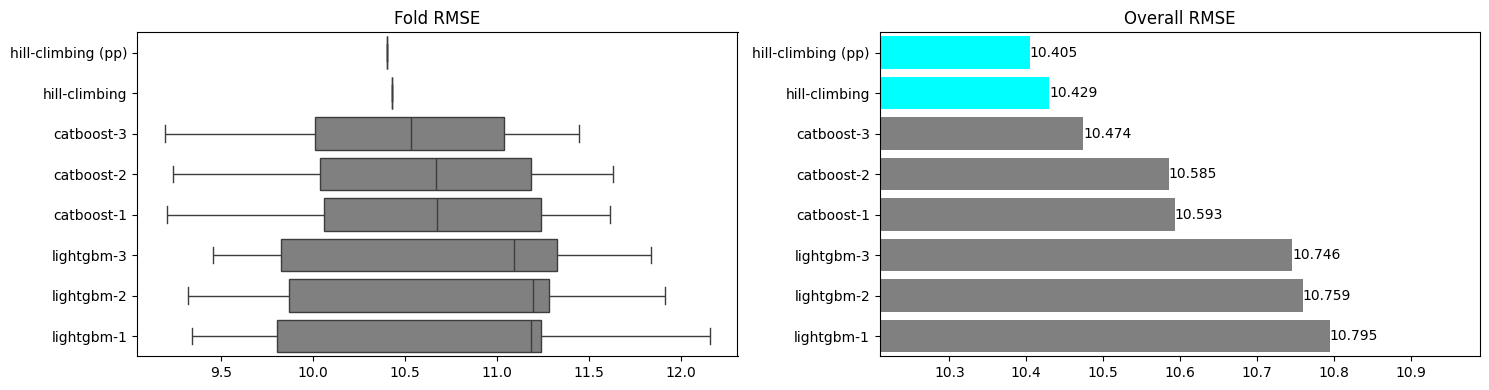

In [15]:
fold_scores_df = pd.DataFrame(fold_scores)
overall_scores_df = pd.DataFrame({k: [v] for k, v in overall_scores.items()}).transpose().sort_values(by=0, ascending=True)
order = overall_scores_df.index.tolist()

min_score = overall_scores_df.values.flatten().min()
max_score = overall_scores_df.values.flatten().max()
padding = (max_score - min_score) * 0.5
lower_limit = min_score - padding
upper_limit = max_score + padding

fig, axs = plt.subplots(1, 2, figsize=(15, fold_scores_df.shape[1] * 0.5))

boxplot = sns.boxplot(data=fold_scores_df, order=order, ax=axs[0], orient="h", color="grey")
axs[0].set_title(f"Fold RMSE")
axs[0].set_xlabel("")
axs[0].set_ylabel("")

barplot = sns.barplot(x=overall_scores_df.values.flatten(), y=overall_scores_df.index, ax=axs[1], color="grey")
axs[1].set_title(f"Overall RMSE")
axs[1].set_xlabel("")
axs[1].set_xlim(left=lower_limit, right=upper_limit)
axs[1].set_ylabel("")

for i, (score, model) in enumerate(zip(overall_scores_df.values.flatten(), overall_scores_df.index)):
    color = "cyan" if "ridge-stack" in model.lower() else "grey"
    barplot.patches[i].set_facecolor(color)
    boxplot.patches[i].set_facecolor(color)
    barplot.text(score, i, round(score, 3), va="center")

plt.tight_layout()
plt.show()